In [11]:
import pandas as pd
import numpy as np
df=pd.read_csv("DecisionTree_Sports.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [12]:
df["Weather"]=np.where(df["Weather"]=="Sunny",2,np.where(df["Weather"]=="Cloudy",0,1))
df["Temperature"]=np.where(df["Temperature"]=="Hot",1,np.where(df["Temperature"]=="Mild",2,0))
df["Humidity"]=np.where(df["Humidity"]=="High",0,1)
df["Wind"]=np.where(df["Wind"]=="Weak",1,0)
df["Play_Sports?"]=np.where(df["Play_Sports?"]=="No",0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,0
1,Day 2,2,1,0,0,0
2,Day 3,0,1,0,1,1
3,Day 4,1,2,0,1,1
4,Day 5,1,0,1,1,1
5,Day 6,1,0,1,0,0
6,Day 7,0,0,1,0,1
7,Day 8,2,2,0,1,0
8,Day 9,2,0,1,1,1
9,Day 10,1,2,1,1,1


In [13]:
x=df[["Weather","Temperature","Humidity","Wind"]]
y=df["Play_Sports?"]
print(x.shape)
print(y.shape)

(14, 4)
(14,)


In [14]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

diff=pd.DataFrame({"Actual Data":y,"Predicted Data":prediction})
diff

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


,Actual Data,Predicted Data
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [15]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)
from sklearn.metrics import accuracy_score
print("accuracy: ",accuracy_score(y,prediction))

[[5 0]
 [0 9]]
accuracy:  1.0


In [16]:
from sklearn import tree
text_representation=tree.export_text(dtree,feature_names=["Weather","Temperature","Humidity","Wind"])
print(text_representation)

|--- Weather <= 0.50
|   |--- class: 1
|--- Weather >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Weather <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Weather >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



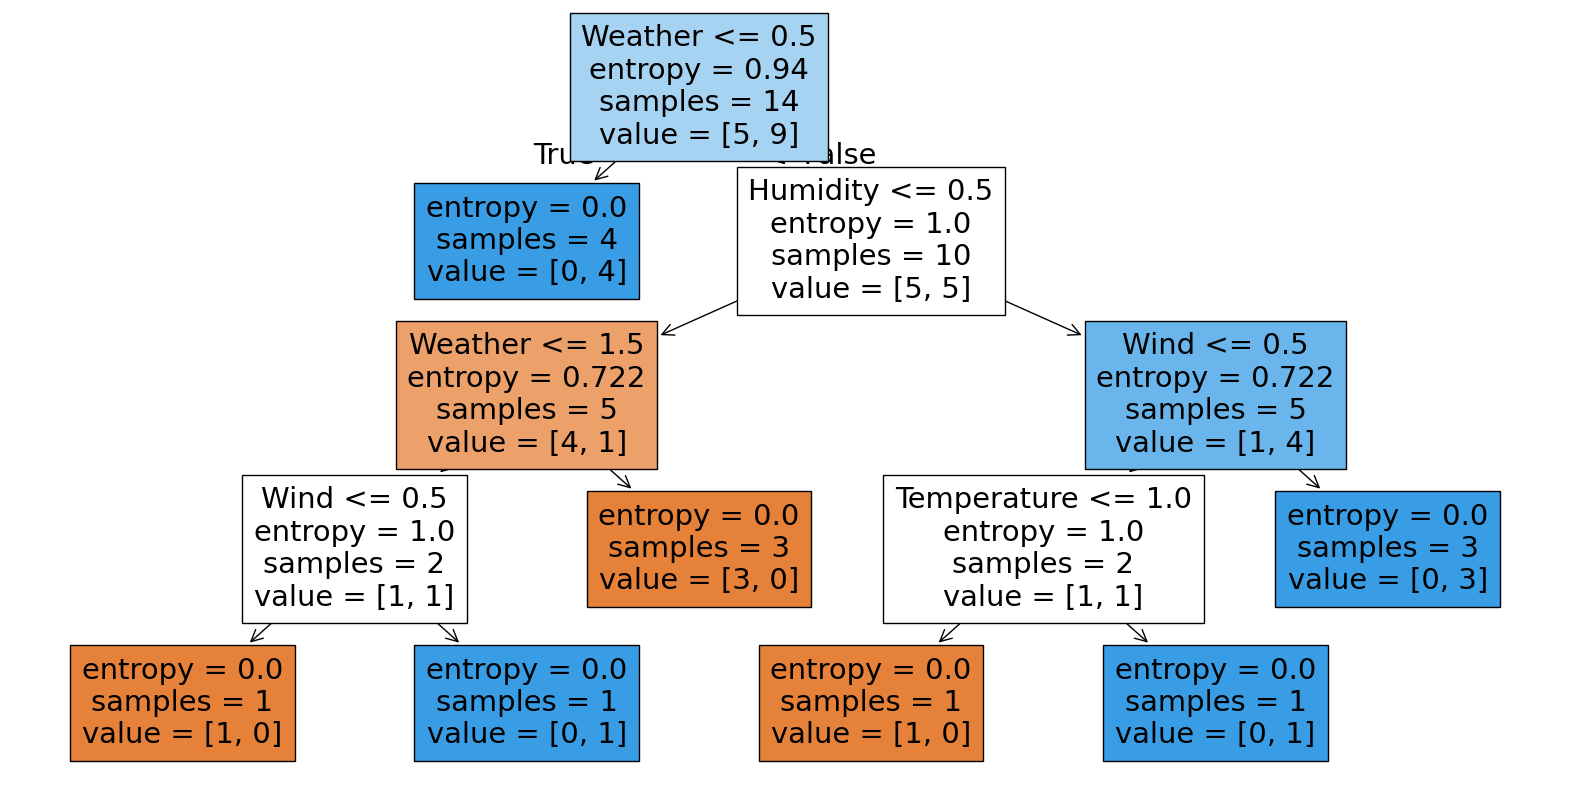

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()

In [10]:
df.to_excel("DecisionTree_Sports1.xlsx")

In [30]:
result=pd.get_dummies(data=df,columns=["Weather","Temperature","Humidity","Wind"])
result

,Day,Play_Sports?,Weather_0,Weather_1,Weather_2,Temperature_0,Temperature_1,Temperature_2,Humidity_0,Humidity_1,Wind_0,Wind_1
0,Day 1,0,False,False,True,False,True,False,True,False,False,True
1,Day 2,0,False,False,True,False,True,False,True,False,True,False
2,Day 3,1,True,False,False,False,True,False,True,False,False,True
3,Day 4,1,False,True,False,False,False,True,True,False,False,True
4,Day 5,1,False,True,False,True,False,False,False,True,False,True
5,Day 6,0,False,True,False,True,False,False,False,True,True,False
6,Day 7,1,True,False,False,True,False,False,False,True,True,False
7,Day 8,0,False,False,True,False,False,True,True,False,False,True
8,Day 9,1,False,False,True,True,False,False,False,True,False,True
9,Day 10,1,False,True,False,False,False,True,False,True,False,True


In [31]:
x=result.iloc[:,2:]
y=result["Play_Sports?"]
print(x.shape)
print(y.shape)

(14, 10)
(14,)


In [32]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

diff=pd.DataFrame({"Actual Data":y,"Predicted Data":prediction})
diff

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


,Actual Data,Predicted Data
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [33]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)
from sklearn.metrics import accuracy_score
print("accuracy: ",accuracy_score(y,prediction))

[[5 0]
 [0 9]]
accuracy:  1.0


In [34]:
from sklearn import tree
text_representation=tree.export_text(dtree,feature_names=list(x.columns))
print(text_representation)

|--- Weather_0 <= 0.50
|   |--- Humidity_1 <= 0.50
|   |   |--- Weather_1 <= 0.50
|   |   |   |--- class: 0
|   |   |--- Weather_1 >  0.50
|   |   |   |--- Wind_1 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind_1 >  0.50
|   |   |   |   |--- class: 1
|   |--- Humidity_1 >  0.50
|   |   |--- Wind_0 <= 0.50
|   |   |   |--- class: 1
|   |   |--- Wind_0 >  0.50
|   |   |   |--- Temperature_0 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Temperature_0 >  0.50
|   |   |   |   |--- class: 0
|--- Weather_0 >  0.50
|   |--- class: 1



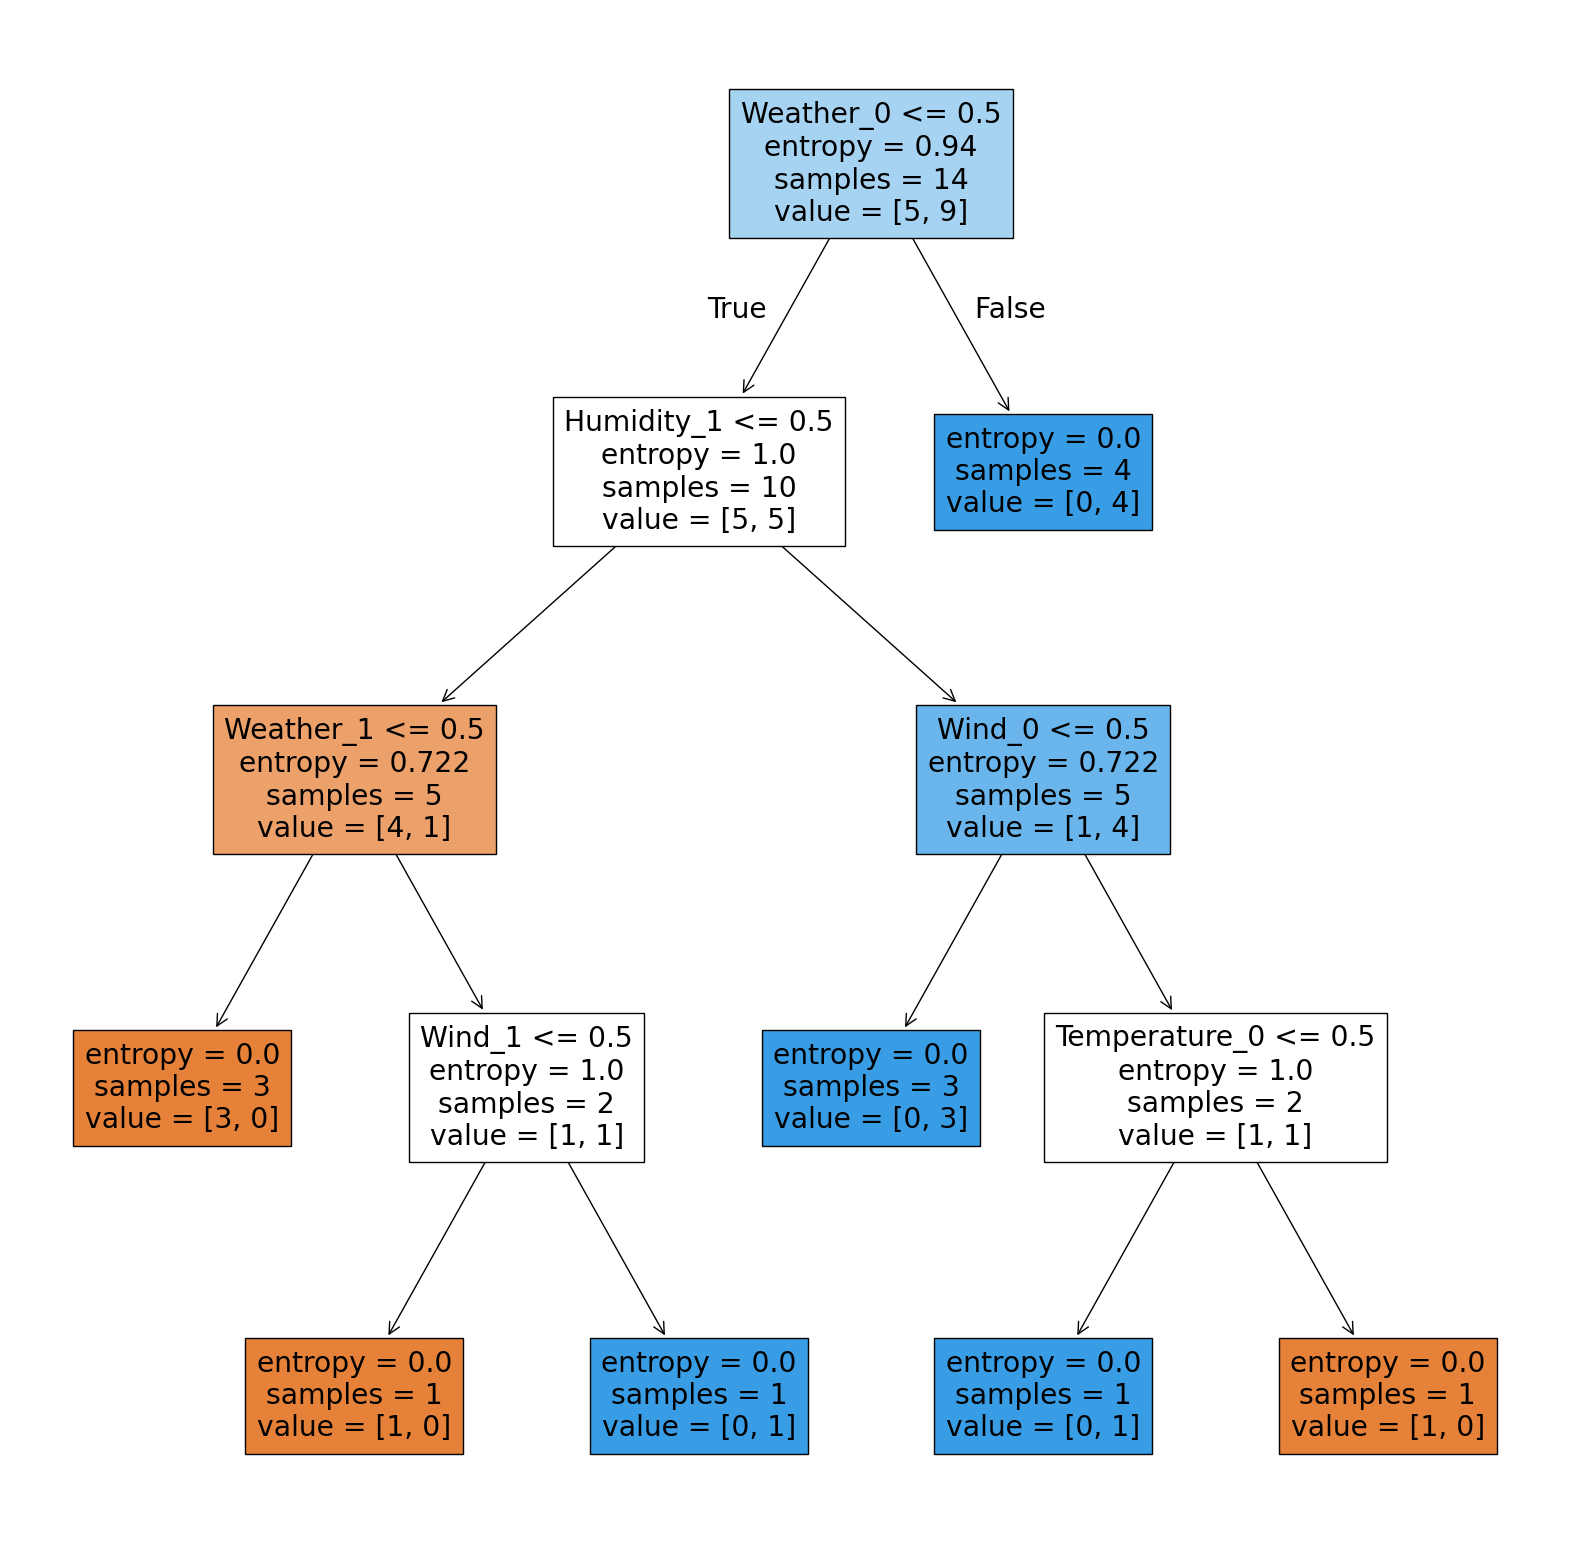

In [36]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()

In [37]:
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [39]:
x=df.iloc[:,0:4]
y=df["Job Offered"]
print(x.shape)
print(y.shape)

(18, 4)
(18,)


In [40]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

diff=pd.DataFrame({"Actual Data":y,"Predicted Data":prediction})
diff

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


,Actual Data,Predicted Data
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


In [41]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)
from sklearn.metrics import accuracy_score
print("accuracy: ",accuracy_score(y,prediction))

from sklearn import tree
text_representation=tree.export_text(dtree,feature_names=list(x.columns))
print(text_representation)

[[10  0]
 [ 0  8]]
accuracy:  1.0
|--- Apptitude <= 0.50
|   |--- class: 0
|--- Apptitude >  0.50
|   |--- Communication <= 0.50
|   |   |--- CGPA <= 1.50
|   |   |   |--- class: 0
|   |   |--- CGPA >  1.50
|   |   |   |--- class: 1
|   |--- Communication >  0.50
|   |   |--- class: 1



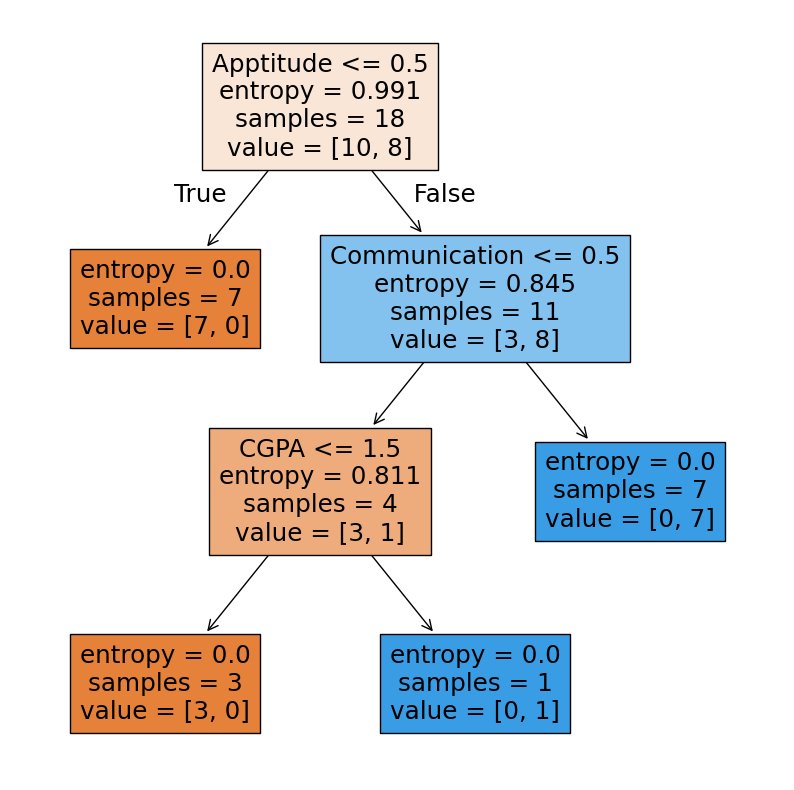

In [44]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()

In [59]:
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [60]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [61]:
df["Age"].fillna(df["Age"].mean(),inplace=True)
df

C:\Users\LJENG\AppData\Local\Temp\ipykernel_9856\2079956988.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [62]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [63]:
x=df[["Pclass","Sex","Age","SibSp","Parch","Fare"]]
y=df["Survived"]
print(x.shape)
print(y.shape)

(891, 6)
(891,)


In [64]:
x["Sex"]=x["Sex"].map({"female":0,"male":1})
x["Age"]=x["Age"].fillna(x["Age"].mean())

C:\Users\LJENG\AppData\Local\Temp\ipykernel_9856\3256429841.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Sex"]=x["Sex"].map({"female":0,"male":1})
C:\Users\LJENG\AppData\Local\Temp\ipykernel_9856\3256429841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Age"]=x["Age"].fillna(x["Age"].mean())


In [65]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.000000,1,0,7.2500
1,1,0,38.000000,1,0,71.2833
2,3,0,26.000000,0,0,7.9250
3,1,0,35.000000,1,0,53.1000
4,3,1,35.000000,0,0,8.0500
...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000
887,1,0,19.000000,0,0,30.0000
888,3,0,29.699118,1,2,23.4500
889,1,1,26.000000,0,0,30.0000


In [76]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

nn=KNeighborsClassifier(n_neighbors=7)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)    
print(prediction)

(712, 6)
(712,)
(179, 6)
(179,)
[1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 1 0 0 0 0 1
 0 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0
 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 0 1]


In [77]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)
from sklearn.metrics import accuracy_score
print("accuracy: ",accuracy_score(y_test,prediction))

[[92 14]
 [33 40]]
accuracy:  0.7374301675977654
